In [550]:
using DifferentialEquations, LinearAlgebra, Plots

In [551]:
#Basis state
r = [0;1]
g = [1;0]

#initial state of the system
α = sqrt(0.5)
β = sqrt(1-α^2)
ψ_a = α.*r + β.*g
ψ_1 = g

n_atoms = 2

ψ_0 = [ψ_a,g,g]
ρ_0 = complex(reduce(kron,ψ_0) * reduce(kron,ψ_0)')

8×8 Matrix{ComplexF64}:
 0.5+0.0im  0.0+0.0im  0.0+0.0im  …  0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.5+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im  …  0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im

In [552]:
ψ_0[1]

2-element Vector{Float64}:
 0.7071067811865475
 0.7071067811865476

In [553]:
function master_eqn(dρ,ρ,p,t)

    #2x2 Matrices
    σ_x = [0 1; 1 0]
    n = [0 0; 0 1]
    Π_g = [1 0; 0 0]
    I = [1 0; 0 1]
    σ_minus = [0 1; 0 0]
    σ_plus = [0 0; 1 0]
    σ_z = [1 0; 0 -1]

    #parameters
    Ω = p[1]
    Δ = p[2]
    γ_D = p[3]
    γ_d = p[4]
    n_atoms = p[5]


    nn_sys = kron(n,n,I) + 1 .*kron(I,n,n)  + (0.5)^6 .*kron(n,I,n)
    σminus_sys,σplus_sys,σz_sys,n_sys,σx_sys = [],[],[],[],[]

    for i in 1:n_atoms

        a,b,c,d,e = [I],[I],[I],[I],[I]

        for j in 1:n_atoms

            if i==j
                push!(a,σ_minus)
                push!(b,σ_plus)
                push!(c,σ_z)
                push!(d,n)
                push!(e,σ_x)
            else
                push!(a,I)
                push!(b,I)
                push!(c,I)
                push!(d,I)
                push!(e,I)
            end
        end
        push!(σminus_sys,reduce(kron,a))
        push!(σplus_sys,reduce(kron,b))
        push!(σz_sys,reduce(kron,c))
        push!(n_sys,reduce(kron,d))
        push!(σx_sys,reduce(kron,e))
    end

    
    H = -Δ .* nn_sys
    l_decay = zeros(2^(n_atoms+1),2^(n_atoms+1))
    l_dephase = zeros(2^(n_atoms+1),2^(n_atoms+1))
    for i in 1:n_atoms
        H += Ω/2 .* σx_sys[i] + Δ .* n_sys[i] 
        l_decay += γ_D.*(σminus_sys[i] * ρ * σplus_sys[i] - 0.5.*((σplus_sys[i]*σminus_sys[i]*ρ)
                         + (ρ*σplus_sys[i]*σminus_sys[i])))
        l_dephase += γ_d.*(σz_sys[i]* ρ *σz_sys[i] - ρ)
    end

    dρ .= -1im .* (H*ρ - ρ*H) + l_decay + l_dephase
end

master_eqn (generic function with 1 method)

In [554]:
tspan = (0.0,2.0)
p = [20,1000,1,10,n_atoms]  #[Ω,Δ,γ_Decay,γ_dephase,num_atoms]

#solving diff master_eqn
eqn = ODEProblem(master_eqn,ρ_0,tspan,p)
sol = solve(eqn,Tsit5(),saveat = 0.01)
println(sol[end])

ComplexF64[0.49561246001018766 + 0.0im -0.004939534906638407 + 0.00010129154806534814im -0.004939534906638403 + 0.0001012915480653474im 9.855878481590167e-5 - 4.612741829687633e-6im 4.49986017411939e-6 - 4.621168462778716e-6im -3.4666598275860664e-8 + 3.0923039784390984e-8im 2.94426090246304e-6 + 3.639823681800422e-6im -7.577170980772183e-7 + 5.046434404306626e-7im; -0.004939534906638407 - 0.00010129154806534814im 0.0015430983376298157 + 0.0im 1.4076622229751932e-5 + 8.097147221535978e-20im -2.1502458009939414e-6 + 7.268760491931103e-5im 4.076915528111181e-7 + 1.1730469279627866e-5im -3.954894582624801e-8 + 2.755037828596478e-7im 1.053358524171552e-5 + 1.2721849872715009e-6im -1.139049481516767e-7 - 3.388054817165336e-5im; -0.004939534906638403 - 0.0001012915480653474im 1.4076622229751932e-5 - 8.097147221535978e-20im 0.0015430983376298155 + 0.0im -2.1502458009940536e-6 + 7.268760491931122e-5im -3.5436756401924864e-5 + 3.134876140555623e-6im 5.869509318655402e-7 + 1.3564927503199592e-8i

In [555]:
# for (t, ρ) in zip(sol.t, sol.u)
#     println("Time: $t, Trace: $(tr(ρ))")
# end

In [556]:
# Example of extracting populations from the solution

n = [0 0; 0 1]
I = [1 0; 0 1]



ryd1_populations = []
ryd2_populations = []
ryd12_populations = []

for ρ in sol.u
    a1 = tr(kron(I,n,I)*ρ)
    a2 = tr(kron(I,I,n)*ρ)
    a12 = tr(kron(I,n,n)*ρ)
    push!(ryd1_populations, a1)
    push!(ryd2_populations,a2)
    push!(ryd12_populations,a12)
end


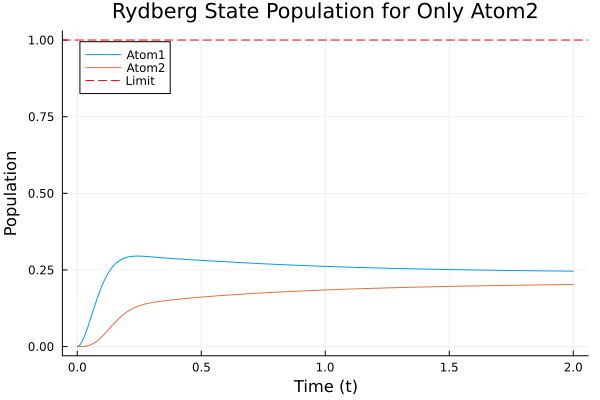

In [557]:
# Plotting the Rydberg state population over time
plot(sol.t, ryd1_populations, label="Atom1", xlabel="Time (t)", ylabel="Population", title="Rydberg State Population for Only Atom1")
plot!(sol.t, ryd2_populations, label="Atom2", xlabel="Time (t)", ylabel="Population", title="Rydberg State Population for Only Atom2")
hline!([1],color=:red,linestyle=:dash,label="Limit")

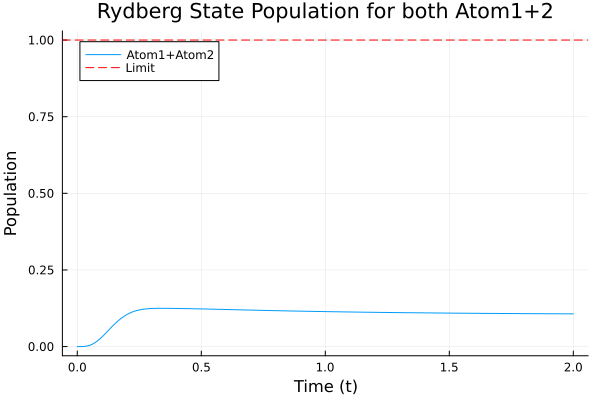

In [558]:
# Plotting the Rydberg state population over time
plot(sol.t, ryd12_populations, label="Atom1+Atom2", xlabel="Time (t)", ylabel="Population", title="Rydberg State Population for both Atom1+2")
hline!([1],color=:red,linestyle=:dash,label="Limit")

In [559]:
# #2x2 Matrices
#     σ_x = [0 1; 1 0]
#     n = [0 0; 0 1]
#     Π_g = [1 0; 0 0]
#     I = [1 0; 0 1]
#     σ_minus = [0 1; 0 0]
#     σ_plus = [0 0; 1 0]
#     σ_z = [1 0; 0 -1]

#     p = [20,1000,0,0,n_atoms]  #[Ω,Δ,γ_Decay,γ_dephase,num_atoms]
#     #parameters
#     Ω = p[1]
#     Δ = p[2]
#     γ_D = p[3]
#     γ_d = p[4]
#     n_atoms = p[5]


#     nn1_sys = kron(Π_g,n,n) + kron(n,n,Π_g) + 2 .*kron(n,n,n)
#     nn2_sys = kron(I,n,n)

#     σminus_sys,σplus_sys,σz_sys,n_sys,σx_sys = [],[],[],[],[]

#     for i in 1:n_atoms

#         a,b,c,d,e = [I],[I],[I],[I],[I]

#         for j in 1:n_atoms

#             if i==j
#                 push!(a,σ_minus)
#                 push!(b,σ_plus)
#                 push!(c,σ_z)
#                 push!(d,n)
#                 push!(e,σ_x)
#             else
#                 push!(a,I)
#                 push!(b,I)
#                 push!(c,I)
#                 push!(d,I)
#                 push!(e,I)
#             end
#         end
#         push!(σminus_sys,reduce(kron,a))
#         push!(σplus_sys,reduce(kron,b))
#         push!(σz_sys,reduce(kron,c))
#         push!(n_sys,reduce(kron,d))
#         push!(σx_sys,reduce(kron,e))
#     end

#     ρ = ρ_0
    
#     H = -Δ .* (nn1_sys + nn2_sys)
#     l_decay = zeros(2^(n_atoms+1),2^(n_atoms+1))
#     l_dephase = zeros(2^(n_atoms+1),2^(n_atoms+1))
#     for i in 1:n_atoms
#         H += Ω/2 .* σx_sys[i] + Δ .* n_sys[i] 
#         l_decay += γ_D.*(σminus_sys[i] * ρ * σplus_sys[i] - 0.5.*((σplus_sys[i]*σminus_sys[i]*ρ)
#                          + (ρ*σplus_sys[i]*σminus_sys[i])))
#         l_dephase += γ_d.*(σz_sys[i]* ρ *σz_sys[i] - ρ)
#     end
